# QAOA para Coloração de Grafos

---

**Algoritmo:** QAOA  
**Framework:** PennyLane  
**Problema:** Coloração de Grafos  

### Grupo 7

> Amanda Arruda • Caio Silva • Diogo Lacerda • Eduarda Mendes • Igor Oliveira  
> Mateus Granha • Paulo Aquino • Rebeca Vitória Tenório • Vinícius Leal

## 1. Instalação e Importações

In [ ]:
!pip install pennylane networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 62.3 MB/s eta 0:00:00


In [ ]:
import pennylane as qml
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize

np.random.seed(42)
print("PennyLane:", qml.__version__)

PennyLane: 0.44.1


## 2. O Problema: Coloração de Grafos

Na coloração de grafos, queremos atribuir cores aos vértices de um grafo de forma que vértices conectados por uma aresta não tenham a mesma cor.

Formalmente, dado um grafo $G = (V, E)$, buscamos uma função que atribua uma cor $c \in \{0, \ldots, k-1\}$ a cada vértice, de modo que para toda aresta $(u,v) \in E$:

$$
f(u) \neq f(v)
$$

Ou seja, dois vértices ligados não podem compartilhar a mesma cor.

O menor número de cores necessário para colorir um grafo dessa forma é chamado de múmero cromático, denotado por $\chi(G)$. Encontrar esse número é um problema computacionalmente difícil; para $k \geq 3$, a decisão de existência de uma coloração válida é NP-completa.

### One-Hot Encoding

Para representar o problema em um computador quântico, usamos uma codificação binária.

Cada vértice $v$ recebe $k$ variáveis binárias $x_{v,0}, \ldots, x_{v,k-1}$, onde

$$
x_{v,c} = 1
$$

indica que o vértice $v$ recebeu a cor $c$.

Como cada vértice deve ter exatamente uma cor, apenas uma dessas variáveis deve ser igual a 1. Esse esquema é chamado de one-hot encoding.

Cada par $(v,c)$ é associado a um qubit cujo índice é definido por

$$
q(v, c) = v \cdot k + c
$$

Assim, o número total de qubits necessários é

$$
n \times k
$$

onde $n$ é o número de vértices e $k$ o número de cores.

### Hamiltoniano de Custo (QUBO -> Ising)

Para resolver o problema com QAOA, precisamos transformá-lo em um problema de otimização. Isso é feito construindo um Hamiltoniano de custo, cuja energia é menor quando a coloração é válida.

Esse Hamiltoniano possui dois termos:

$$
H_C =
\underbrace{\sum_{(u,v)\in E}\sum_c x_{u,c}x_{v,c}}_{\text{conflitos}}
+
A\underbrace{\sum_v\left(\sum_c x_{v,c}-1\right)^2}_{\text{restrição one-hot}}
$$

O primeiro termo penaliza conflitos de cor, isto é, quando dois vértices conectados recebem a mesma cor.

O segundo termo impõe a restrição one-hot, garantindo que cada vértice receba exatamente uma cor. O parâmetro $A$ controla a intensidade dessa penalização.

Para implementar esse Hamiltoniano em um circuito quântico, usamos a transformação padrão

$$
x_i = \frac{1 - Z_i}{2}
$$

que converte variáveis binárias em operadores de Pauli. Após essa substituição, cada produto $x_i x_j$ se transforma em combinações de $Z_i$, $Z_j$ e $Z_i Z_j$, que podem ser implementadas diretamente no circuito quântico.

## 3. Definindo o Grafo

**Experimento 1:** caminho $P_3$ com 3 vértices e 2 cores (nosso grafo de validação, porque já tem solução ótima conhecida).

**Experimento 2:** ciclo $C_5$ com 5 vértices e 3 cores (número cromático $\chi = 3$).

**Experimento 3:** grafo completo $K_4$ com 4 vértices e 4 cores (número cromático $\chi = 4$).

Exp 1: 3 vértices, 2 cores, 6 qubits
Exp 2: 5 vértices, 3 cores, 15 qubits
Exp 3: 4 vértices, 4 cores, 16 qubits


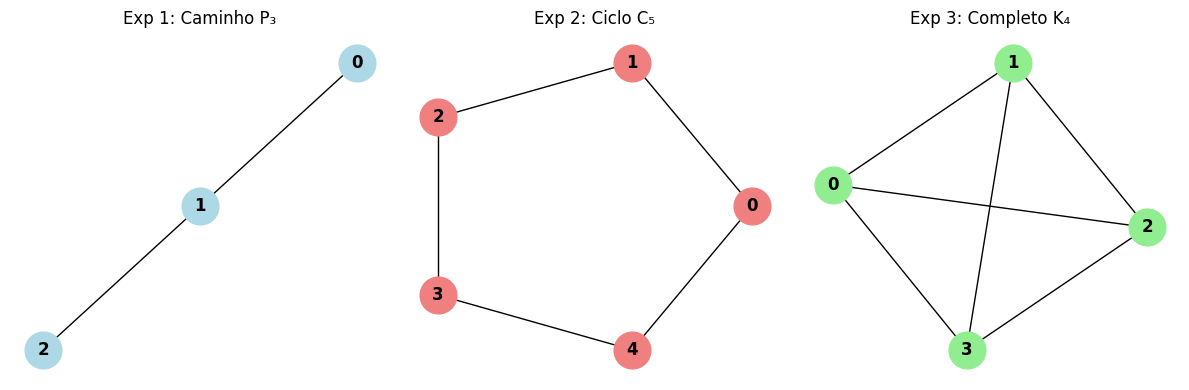

In [ ]:
# Experimento 1: caminho P3
n_nos_1, k_cores_1 = 3, 2
arestas_1 = [(0,1), (1,2)]
G1 = nx.path_graph(n_nos_1)
n_qubits_1 = n_nos_1 * k_cores_1

# Experimento 2: ciclo C5
n_nos_2, k_cores_2 = 5, 3
arestas_2 = [(0,1),(1,2),(2,3),(3,4),(4,0)]
G2 = nx.cycle_graph(n_nos_2)
n_qubits_2 = n_nos_2 * k_cores_2

# Experimento 3: completo K4
n_nos_3, k_cores_3 = 4, 4
G3 = nx.complete_graph(n_nos_3)
arestas_3 = list(G3.edges())
n_qubits_3 = n_nos_3 * k_cores_3

print(f"Exp 1: {n_nos_1} vértices, {k_cores_1} cores, {n_qubits_1} qubits")
print(f"Exp 2: {n_nos_2} vértices, {k_cores_2} cores, {n_qubits_2} qubits")
print(f"Exp 3: {n_nos_3} vértices, {k_cores_3} cores, {n_qubits_3} qubits")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
pos1 = nx.spring_layout(G1, seed=1)
pos2 = nx.circular_layout(G2)
pos3 = nx.spring_layout(G3, seed=7)

nx.draw(G1, pos1, ax=axes[0], with_labels=True, node_color='lightblue',
        node_size=700, font_weight='bold')
axes[0].set_title("Exp 1: Caminho P₃")

nx.draw(G2, pos2, ax=axes[1], with_labels=True, node_color='lightcoral',
        node_size=700, font_weight='bold')
axes[1].set_title("Exp 2: Ciclo C₅")

nx.draw(G3, pos3, ax=axes[2], with_labels=True, node_color='lightgreen',
        node_size=700, font_weight='bold')
axes[2].set_title("Exp 3: Completo K₄")

plt.tight_layout(); plt.show()

## 4. Construindo o Hamiltoniano de Custo

A função abaixo constrói explicitamente o Hamiltoniano de custo a partir do grafo.  
A ideia é converter a formulação QUBO da seção anterior em uma soma de operadores de Pauli que possa ser usada diretamente no QAOA.

Internamente, o Hamiltoniano é representado por três partes:

- **termos lineares** \(Z_i\), armazenados no vetor `h`;
- **termos quadráticos** \(Z_i Z_j\), armazenados na matriz `J`;
- **um termo constante**, `cst`, que não afeta a dinâmica do circuito, mas é útil para calcular o valor ótimo teórico da função custo.

Primeiro adicionamos os termos de **conflito**.  
Para cada aresta \((u,v)\) e para cada cor \(c\), penalizamos situações em que os dois vértices recebem a mesma cor. Após a transformação \(x_i = (1-Z_i)/2\), cada produto $x_{u,c}x_{v,c}$ gera contribuições lineares em $Z_i$, $Z_j$ e um termo quadrático $Z_i Z_j$.

Em seguida adicionamos o termo de **penalidade one-hot**, que garante que cada vértice receba exatamente uma cor. Esse termo expande a expressão $(\sum_c x_{v,c} - 1)^2$, produzindo novamente termos lineares e quadráticos entre os qubits associados ao mesmo vértice.

O parâmetro \(A\) controla o peso dessa penalização. Neste notebook utilizamos \(A = 5\), valor suficiente para favorecer estados que respeitam a restrição de uma única cor por vértice.

Por fim, os coeficientes são convertidos para uma lista de operadores de $Pauli Z$ e $Z \otimes Z$, formando o Hamiltoniano que será usado pelo QAOA.

In [ ]:
def indice_qubit(v, c, k):
    return v * k + c

def construir_hamiltoniano(n, k, arestas, A=5.0):
    n_q = n * k
    h = np.zeros(n_q) # coef. lineares (Z_i)
    J = np.zeros((n_q, n_q)) # coef. quadraticos (Z_i Z_j)
    cst = 0.0

    # H_conflito: penaliza arestas com mesma cor
    for (u, v) in arestas:
        for c in range(k):
            i, j = indice_qubit(u,c,k), indice_qubit(v,c,k)
            cst += 0.25; h[i] -= 0.25; h[j] -= 0.25; J[i][j] += 0.25

    # H_penalidade: cada vertice deve ter exatamente 1 cor
    for v in range(n):
        qv = [indice_qubit(v,c,k) for c in range(k)]
        cst += A
        for c in range(k):
            cst -= A*0.5; h[qv[c]] += A*0.5
        for c1 in range(k):
            for c2 in range(c1+1, k):
                cst += A*0.5
                h[qv[c1]] -= A*0.5; h[qv[c2]] -= A*0.5
                J[qv[c1]][qv[c2]] += A*0.5

    coefs, obs = [], []
    for i in range(n_q):
        if abs(h[i]) > 1e-10: coefs.append(h[i]); obs.append(qml.PauliZ(i))
    for i in range(n_q):
        for j in range(i+1, n_q):
            if abs(J[i][j]) > 1e-10:
                coefs.append(J[i][j]); obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
    return coefs, obs, cst

coefs_1, obs_1, cst_1 = construir_hamiltoniano(n_nos_1, k_cores_1, arestas_1)
coefs_2, obs_2, cst_2 = construir_hamiltoniano(n_nos_2, k_cores_2, arestas_2)
coefs_3, obs_3, cst_3 = construir_hamiltoniano(n_nos_3, k_cores_3, arestas_3)

print(f"Exp 1 - {len(coefs_1)} termos de Pauli | custo ótimo: {-cst_1:.2f}")
print(f"Exp 2 - {len(coefs_2)} termos de Pauli | custo ótimo: {-cst_2:.2f}")
print(f"Exp 3 - {len(coefs_3)} termos de Pauli | custo ótimo: {-cst_3:.2f}")

Exp 1 - 13 termos de Pauli | custo ótimo: -8.50
Exp 2 - 42 termos de Pauli | custo ótimo: -28.75
Exp 3 - 64 termos de Pauli | custo ótimo: -46.00


## 5. Circuito QAOA

O circuito possui $p$ camadas variacionais, cada uma composta por duas evoluções unitárias parametrizadas.

A **camada de custo** aplica a evolução gerada pelo Hamiltoniano $H_C$:

$$
U_C(\gamma) = e^{-i\gamma H_C}
$$

Como $H_C$ é escrito em termos de operadores $Z_i$ e $Z_i Z_j$, essa evolução pode ser implementada diretamente com rotações $R_Z$ e interações $R_{ZZ}$ nos qubits correspondentes.

A seguir aplicamos a **camada mixer**, definida por

$$
U_M(\beta) = e^{-i\beta H_M}, \quad H_M = \sum_i X_i
$$

Na prática, isso corresponde a aplicar rotações $R_X(2\beta)$ em todos os qubits. Essa etapa mistura amplitudes entre diferentes estados da base computacional, permitindo que o algoritmo explore o espaço de soluções.

O circuito começa no estado de **superposição uniforme**

$$
|+\rangle^{\otimes nk}
$$

preparado aplicando portas de Hadamard em todos os qubits. A partir desse estado inicial, as camadas de custo e mixer são alternadas $p$ vezes, formando o ansatz variacional do QAOA.

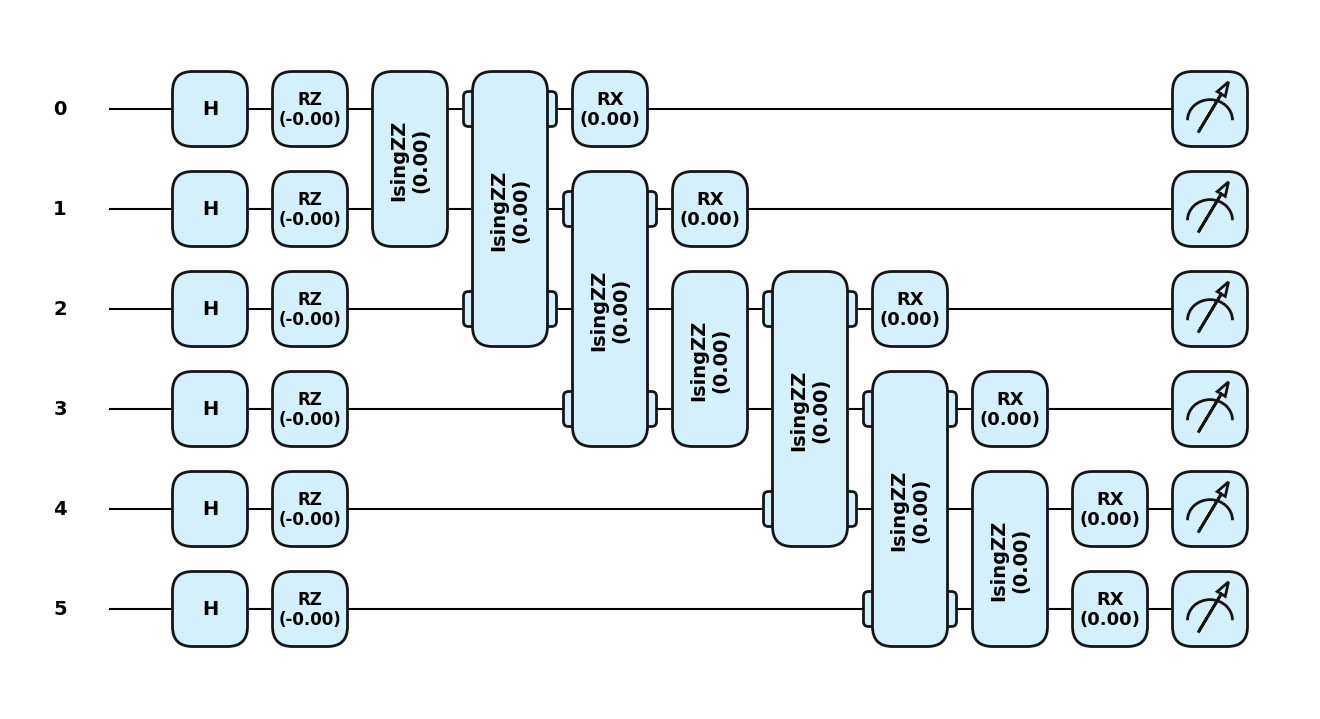

In [ ]:
def circuito_qaoa(params, coefs, obs, n_qubits, p):
    # Aplica p camadas QAOA. params = [gamma_1,...,gamma_p, beta_1,...,beta_p]
    gammas, betas = params[:p], params[p:]
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
    for camada in range(p):
        # Camada de custo
        for coef, op in zip(coefs, obs):
            if len(op.wires) == 1:
                qml.RZ(2 * gammas[camada] * coef, wires=op.wires[0])
            else:
                qml.IsingZZ(2 * gammas[camada] * coef, wires=list(op.wires))
        # Camada mixer
        for i in range(n_qubits):
            qml.RX(2 * betas[camada], wires=i)

def criar_qnode(n_qubits, coefs, obs, p):
    dev = qml.device('default.qubit', wires=n_qubits)
    H   = qml.Hamiltonian(coefs, obs)
    @qml.qnode(dev)
    def custo(params):
        circuito_qaoa(params, coefs, obs, n_qubits, p)
        return qml.expval(H)
    return custo

# Visualizando o circuito (p=1, Exp 1)
circ_vis = criar_qnode(n_qubits_1, coefs_1, obs_1, p=1)
qml.drawer.use_style("pennylane")
qml.draw_mpl(circ_vis, decimals=2)(np.zeros(2))
plt.show()

## 6. Otimização

Usamos o **COBYLA** (livre de gradiente, robusto para funções ruidosas) para minimizar $\langle H_C \rangle$.

Como a paisagem tem múltiplos mínimos locais, repetimos com **10 inicializações aleatórias** em $[-\pi, \pi]$ e guardamos o melhor resultado.

Otimizando Experimento 1...
  Custo final: -7.2454  |  ótimo teórico: -8.5000


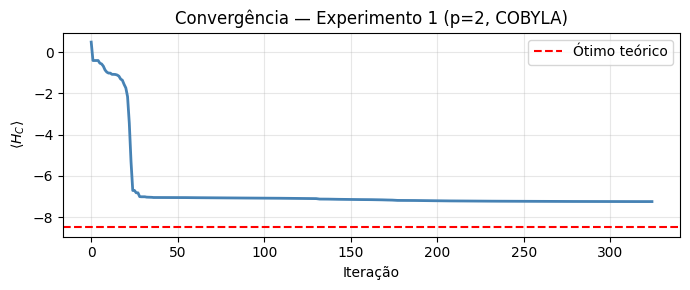

In [ ]:
def otimizar(n_qubits, coefs, obs, p=2, n_iter=400, n_restarts=10, seed=42):
    """Minimiza <H_C> com COBYLA usando múltiplos restarts."""
    cost_fn = criar_qnode(n_qubits, coefs, obs, p)
    melhor, melhor_hist = None, []

    for r in range(n_restarts):
        np.random.seed(seed + r)
        p0 = np.random.uniform(-np.pi, np.pi, 2*p)
        hist = []
        res = minimize(lambda x: float(cost_fn(x)), p0, method='COBYLA',
                       callback=lambda x: hist.append(float(cost_fn(x))),
                       options={'maxiter': n_iter, 'rhobeg': 0.8})
        if melhor is None or res.fun < melhor.fun:
            melhor, melhor_hist = res, hist

    return melhor, melhor_hist

# Experimento 1 (p=2, 10 restarts)
print("Otimizando Experimento 1...")
res_1, hist_1 = otimizar(n_qubits_1, coefs_1, obs_1, p=2)
print(f"  Custo final: {res_1.fun:.4f}  |  ótimo teórico: {-cst_1:.4f}")

plt.figure(figsize=(7,3))
plt.plot(hist_1, color='steelblue', lw=2)
plt.axhline(-cst_1, color='red', ls='--', label='Ótimo teórico')
plt.xlabel("Iteração"); plt.ylabel(r"$\langle H_C \rangle$")
plt.title("Convergência — Experimento 1 (p=2, COBYLA)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Observa-se uma queda rápida do valor esperado $\langle H_C \rangle$ nas primeiras iterações, indicando que o otimizador encontra rapidamente regiões de menor energia no espaço de parâmetros. A convergência ocorre por volta de 30 iterações, estabilizando em um valor próximo de $-7.25$.

Embora o algoritmo não atinja o ótimo teórico ($-8.5$), o resultado obtido já corresponde a uma configuração de baixa energia e próxima da solução ótima.

## 7. Decodificação das Soluções

Após otimizar, amostramos o circuito e decodificamos as bitstrings. Retornamos a **melhor solução válida** (menor número de conflitos) entre todas as amostras.

In [ ]:
def amostrar(params, coefs, obs, n_qubits, p, shots=4096):
    dev = qml.device('default.qubit', wires=n_qubits, shots=shots)
    @qml.qnode(dev)
    def circ(params):
        circuito_qaoa(params, coefs, obs, n_qubits, p)
        return qml.sample(wires=range(n_qubits))
    amostras = circ(params)
    contagens = {}
    for a in amostras:
        bs = ''.join(str(b) for b in a)
        contagens[bs] = contagens.get(bs, 0) + 1
    return contagens

def decodificar(bs, n, k):
    cores, ok = [], True
    for v in range(n):
        bits = [int(bs[indice_qubit(v,c,k)]) for c in range(k)]
        if sum(bits) == 1:
            cores.append(bits.index(1))
        else:
            cores.append(-1)
            ok = False
    return cores, ok

def melhor_solucao(contagens, n, k, arestas):
    melhor_bs, melhor_conf, melhor_cnt = None, float('inf'), 0
    for bs, cnt in contagens.items():
        cores, ok = decodificar(bs, n, k)
        if not ok:
            continue
        conf = sum(1 for u,v in arestas if cores[u]==cores[v])
        if conf < melhor_conf or (conf == melhor_conf and cnt > melhor_cnt):
            melhor_bs, melhor_conf, melhor_cnt = bs, conf, cnt

    if melhor_bs is None:
        # Fallback: se não houver bitstring válida, usa a mais frequente para manter o fluxo.
        melhor_bs = max(contagens.items(), key=lambda x: x[1])[0]
        cores_fb, ok_fb = decodificar(melhor_bs, n, k)
        melhor_conf = sum(1 for u,v in arestas if cores_fb[u]==cores_fb[v]) if ok_fb else len(arestas)
        print("Aviso: nenhuma bitstring one-hot válida encontrada; usando bitstring mais frequente como fallback.")

    return melhor_bs, melhor_conf

# Amostragem Experimento 1
cont_1 = amostrar(res_1.x, coefs_1, obs_1, n_qubits_1, p=2)
bs_1, conf_1 = melhor_solucao(cont_1, n_nos_1, k_cores_1, arestas_1)
cores_1, _ = decodificar(bs_1, n_nos_1, k_cores_1)
print(f"Melhor solução: {bs_1} | cores={cores_1} | conflitos={conf_1}")

Melhor solução: 100110 | cores=[0, 1, 0] | conflitos=0


c:\Users\paulo\Documents\brazil quantum camp\qaoa_graph_coloring\.venv\Lib\site-packages\pennylane\devices\device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


## 8. Resultado do Experimento 1

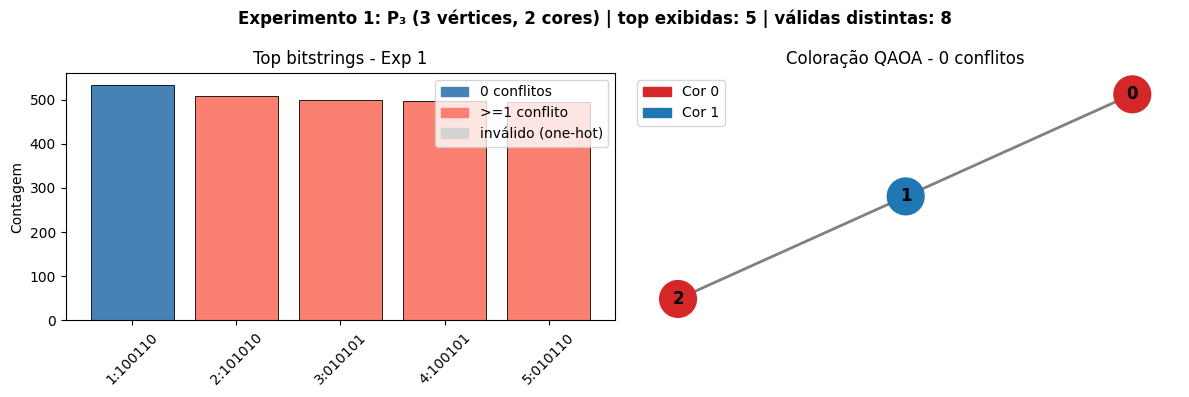

Solução clássica (greedy): cores = [1, 0, 1] | conflitos = 0
Solução QAOA: cores = [0, 1, 0]  | conflitos = 0


In [ ]:
# Top bitstrings e grafo colorido

def cor_barra(bs, n, k, arestas):
    c, ok = decodificar(bs, n, k)
    if not ok:
        return 'lightgray'
    return 'steelblue' if sum(1 for u,v in arestas if c[u]==c[v])==0 else 'salmon'

def top_para_plot(contagens, n, k, arestas, max_itens=5):
    # Prioriza bitstrings válidas para reduzir barras cinza no histograma.
    ordenado = sorted(contagens.items(), key=lambda x: -x[1])
    validas, invalidas = [], []
    for bs, cnt in ordenado:
        cores, ok = decodificar(bs, n, k)
        if ok:
            conf = sum(1 for u,v in arestas if cores[u]==cores[v])
            validas.append((bs, cnt, conf))
        else:
            invalidas.append((bs, cnt, -1))

    escolhidas = validas[:max_itens]
    if len(escolhidas) < max_itens:
        escolhidas += invalidas[:max_itens-len(escolhidas)]

    bs = [x[0] for x in escolhidas]
    cnt = [x[1] for x in escolhidas]
    cores = [cor_barra(x[0], n, k, arestas) for x in escolhidas]
    lbl = [f"{i+1}:{(b[:9]+'...' if len(b) > 9 else b)}" for i, b in enumerate(bs)]
    n_validas_total = len(validas)
    return bs, cnt, cores, lbl, n_validas_total

paleta = ['tab:red','tab:blue','tab:green','tab:orange','tab:purple']

top_bs, top_cnt, cores_b, top_lbl, n_validas = top_para_plot(cont_1, n_nos_1, k_cores_1, arestas_1, max_itens=5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].bar(top_lbl, top_cnt, color=cores_b, edgecolor='black', lw=0.6)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Contagem"); axes[0].set_title("Top bitstrings - Exp 1")
axes[0].legend(handles=[
    mpatches.Patch(color='steelblue', label='0 conflitos'),
    mpatches.Patch(color='salmon', label='>=1 conflito'),
    mpatches.Patch(color='lightgray', label='inválido (one-hot)')
])

# Grafo colorido
node_col = [paleta[c] if c!=-1 else 'lightgray' for c in cores_1]
nx.draw(G1, pos1, ax=axes[1], with_labels=True, node_color=node_col,
        node_size=700, font_weight='bold', edge_color='gray', width=2)
arestas_conf = [(u,v) for u,v in arestas_1 if cores_1[u]==cores_1[v] and cores_1[u]!=-1]
if arestas_conf:
    nx.draw_networkx_edges(G1, pos1, ax=axes[1], edgelist=arestas_conf,
                           edge_color='red', width=3)
status = "0 conflitos" if conf_1==0 else f"{conf_1} conflito(s)"
axes[1].set_title(f"Coloração QAOA - {status}")
axes[1].legend(handles=[mpatches.Patch(color=paleta[c], label=f'Cor {c}')
                         for c in range(k_cores_1)])
plt.suptitle(f"Experimento 1: P₃ (3 vértices, 2 cores) | top exibidas: {len(top_bs)} | válidas distintas: {n_validas}", fontweight='bold')
plt.tight_layout(); plt.show()

# Comparação clássica
cl = nx.coloring.greedy_color(G1, strategy='largest_first')
cores_cl = [cl[v] for v in range(n_nos_1)]
conf_cl  = sum(1 for u,v in arestas_1 if cores_cl[u]==cores_cl[v])
print(f"Solução clássica (greedy): cores = {cores_cl} | conflitos = {conf_cl}")
print(f"Solução QAOA: cores = {cores_1}  | conflitos = {conf_1}")

## 9. Efeito do Número de Camadas $p$ (Experimentos 1, 2 e 3)

Para manter a análise modular, repetimos o estudo de profundidade para todos os experimentos. Em cada caso, comparamos $p \in \{1,2,3\}$ e observamos convergência e custo final.


=== Experimento 1 (P₃) | Efeito de p ===
Rodando p=1...
  custo=-4.6280  gap=+3.8720
Rodando p=2...
  custo=-7.2454  gap=+1.2546
Rodando p=3...
  custo=-7.2191  gap=+1.2809


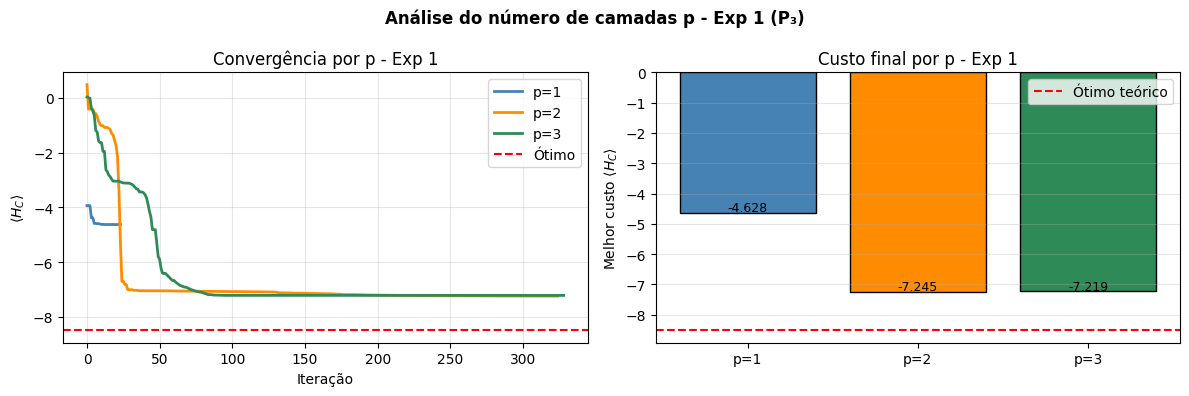


=== Experimento 2 (C₅) | Efeito de p ===
Rodando p=1...
  custo=-7.1888  gap=+21.5612
Rodando p=2...
  custo=-20.1579  gap=+8.5921
Rodando p=3...
  custo=-18.5345  gap=+10.2155


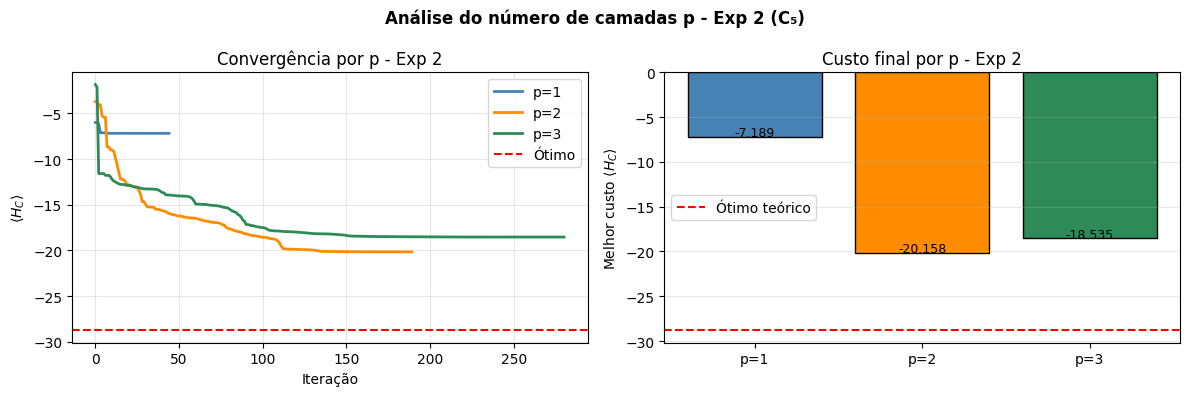


=== Experimento 3 (K₄) | Efeito de p ===
Rodando p=1...
  custo=-35.3751  gap=+10.6249
Rodando p=2...
  custo=-35.3776  gap=+10.6224
Rodando p=3...
  custo=-38.4303  gap=+7.5697


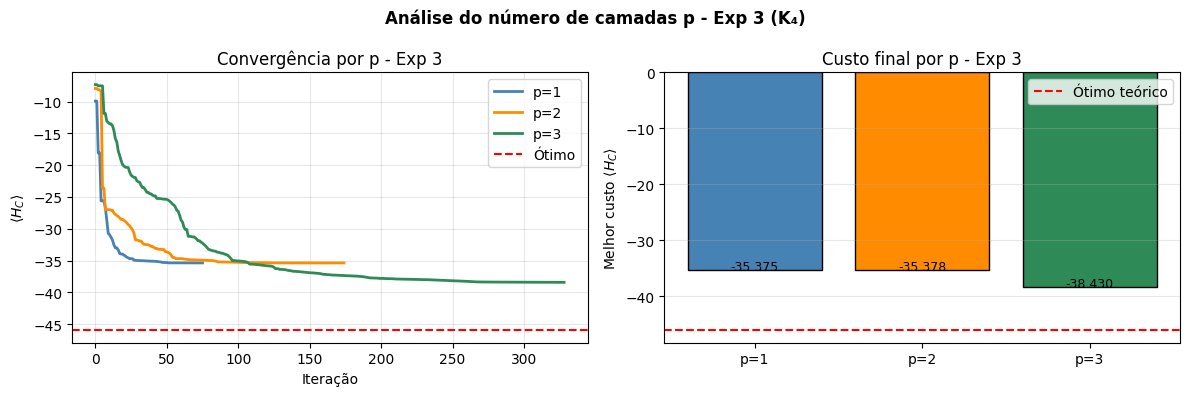

In [ ]:
experimentos = [
    {
        'id': 1,
        'nome': 'P₃',
        'n_qubits': n_qubits_1,
        'coefs': coefs_1,
        'obs': obs_1,
        'cst': cst_1,
    },
    {
        'id': 2,
        'nome': 'C₅',
        'n_qubits': n_qubits_2,
        'coefs': coefs_2,
        'obs': obs_2,
        'cst': cst_2,
    },
    {
        'id': 3,
        'nome': 'K₄',
        'n_qubits': n_qubits_3,
        'coefs': coefs_3,
        'obs': obs_3,
        'cst': cst_3,
    }
]

valores_p = [1, 2, 3]
cores_p = ['steelblue', 'darkorange', 'seagreen']

for exp in experimentos:
    print(f"\n=== Experimento {exp['id']} ({exp['nome']}) | Efeito de p ===")
    resultados_p = {}

    for p in valores_p:
        print(f"Rodando p={p}...")
        # Menos restarts para manter tempo viável nos experimentos maiores.
        n_restarts_local = 8 if exp['id'] == 1 else 4
        res, hist = otimizar(exp['n_qubits'], exp['coefs'], exp['obs'], p=p, n_restarts=n_restarts_local)
        resultados_p[p] = {'res': res, 'hist': hist}
        print(f"  custo={res.fun:.4f}  gap={res.fun-(-exp['cst']):+.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for p, cor in zip(valores_p, cores_p):
        axes[0].plot(resultados_p[p]['hist'], label=f'p={p}', color=cor, lw=2)
    axes[0].axhline(-exp['cst'], color='red', ls='--', label='Ótimo')
    axes[0].set_xlabel("Iteração"); axes[0].set_ylabel(r"$\langle H_C \rangle$")
    axes[0].set_title(f"Convergência por p - Exp {exp['id']}")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    custos = [resultados_p[p]['res'].fun for p in valores_p]
    bars = axes[1].bar([f'p={p}' for p in valores_p], custos, color=cores_p, edgecolor='black')
    axes[1].axhline(-exp['cst'], color='red', ls='--', label='Ótimo teórico')
    for bar, v in zip(bars, custos):
        axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.05,
                     f'{v:.3f}', ha='center', fontsize=9)
    axes[1].set_ylabel(r"Melhor custo $\langle H_C \rangle$")
    axes[1].set_title(f"Custo final por p - Exp {exp['id']}")
    axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle(f"Análise do número de camadas p - Exp {exp['id']} ({exp['nome']})", fontweight='bold')
    plt.tight_layout(); plt.show()

De forma geral, aumentar o número de camadas $p$ melhora a qualidade da solução também nos Experimentos 2 e 3, mas com custo computacional maior. O ganho típico de $p=1$ para $p=2$ tende a ser mais relevante do que de $p=2$ para $p=3$, indicando retornos decrescentes conforme a profundidade cresce.

## 10. Comparação de Otimizadores (Experimentos 1, 2 e 3)

Também de forma modular, comparamos COBYLA, Nelder-Mead e L-BFGS-B em todos os experimentos, mantendo $p=2$.


=== Experimento 1 (P₃) | Comparação de otimizadores ===
Rodando COBYLA...
  custo=-7.4261 | parou na iteração 259
Rodando Nelder-Mead...


C:\Users\paulo\AppData\Local\Temp\ipykernel_4940\70919154.py:19: OptimizeWarning: Unknown solver options: rhobeg
  res = minimize(


  custo=-7.3304 | parou na iteração 159
Rodando L-BFGS-B...
  custo=-7.3677 | parou na iteração 14

Otimizador     | Iterações |  Custo final
------------------------------------------
COBYLA         |       259 |      -7.4261
Nelder-Mead    |       159 |      -7.3304
L-BFGS-B       |        14 |      -7.3677


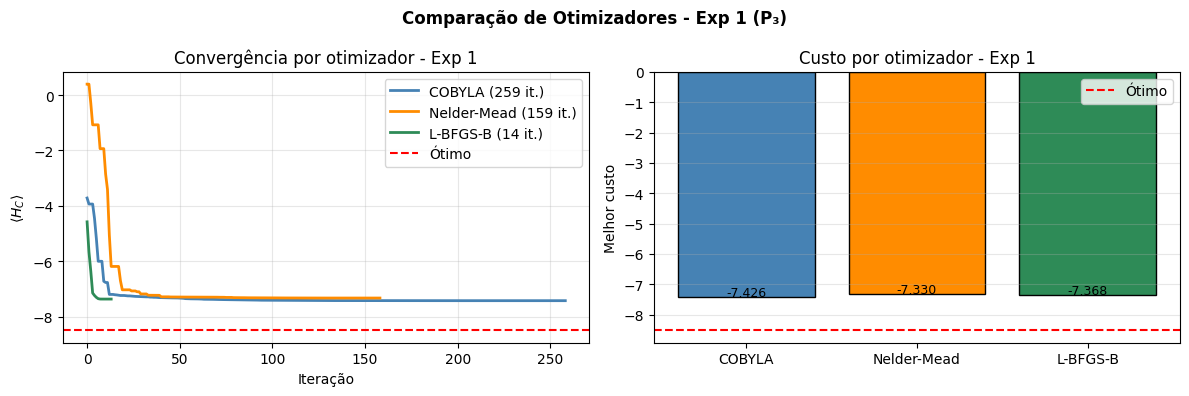


=== Experimento 2 (C₅) | Comparação de otimizadores ===
Rodando COBYLA...
  custo=-14.1418 | parou na iteração 175
Rodando Nelder-Mead...
  custo=-17.3436 | parou na iteração 142
Rodando L-BFGS-B...
  custo=-23.2659 | parou na iteração 19

Otimizador     | Iterações |  Custo final
------------------------------------------
COBYLA         |       175 |     -14.1418
Nelder-Mead    |       142 |     -17.3436
L-BFGS-B       |        19 |     -23.2659


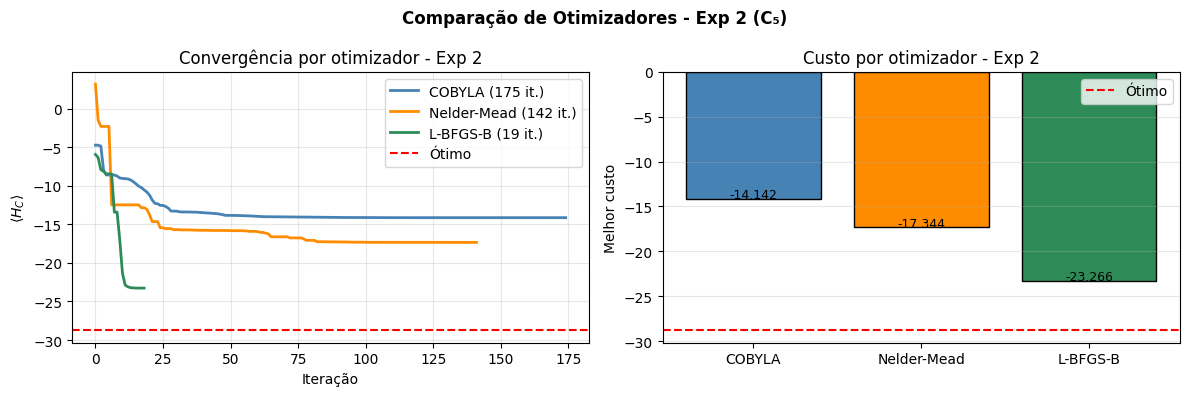


=== Experimento 3 (K₄) | Comparação de otimizadores ===
Rodando COBYLA...
  custo=-35.3325 | parou na iteração 324
Rodando Nelder-Mead...
  custo=-37.6164 | parou na iteração 93
Rodando L-BFGS-B...
  custo=-21.5709 | parou na iteração 20

Otimizador     | Iterações |  Custo final
------------------------------------------
COBYLA         |       324 |     -35.3325
Nelder-Mead    |        93 |     -37.6164
L-BFGS-B       |        20 |     -21.5709


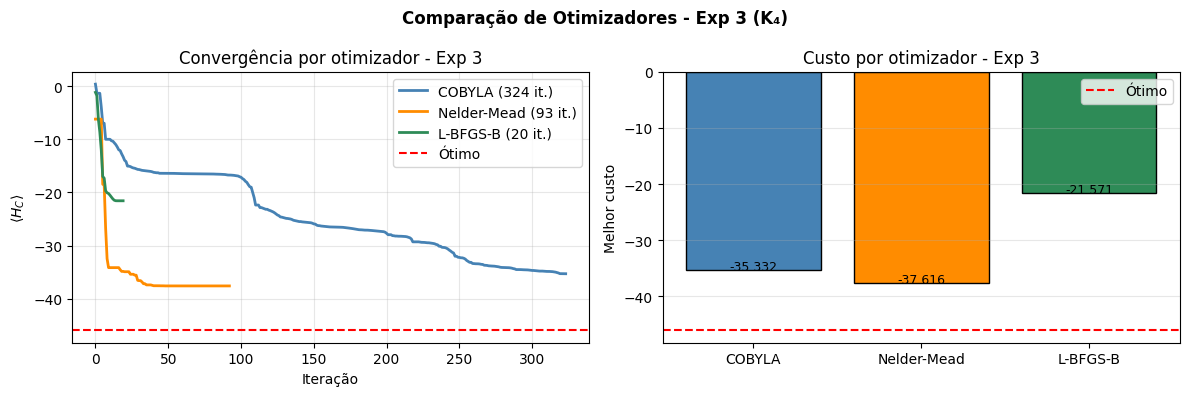

In [ ]:
metodos = ['COBYLA', 'Nelder-Mead', 'L-BFGS-B']
cores_m = ['steelblue', 'darkorange', 'seagreen']

for exp in experimentos:
    print(f"\n=== Experimento {exp['id']} ({exp['nome']}) | Comparação de otimizadores ===")
    resultados_m = {}

    for metodo in metodos:
        print(f"Rodando {metodo}...")
        cost_fn = criar_qnode(exp['n_qubits'], exp['coefs'], exp['obs'], p=2)
        melhor, melhor_hist = None, []

        n_restarts_local = 6 if exp['id'] == 1 else 3
        for r in range(n_restarts_local):
            np.random.seed(r)
            p0 = np.random.uniform(-np.pi, np.pi, 4)
            hist = []
            options = {'maxiter': 400, 'rhobeg': 0.8} if metodo != 'L-BFGS-B' else {'maxiter': 400}
            res = minimize(
                lambda x: float(cost_fn(x)),
                p0,
                method=metodo,
                callback=lambda x: hist.append(float(cost_fn(x))),
                options=options,
            )
            if melhor is None or res.fun < melhor.fun:
                melhor, melhor_hist = res, hist

        resultados_m[metodo] = {'res': melhor, 'hist': melhor_hist}
        print(f"  custo={melhor.fun:.4f} | parou na iteração {len(melhor_hist)}")

    print()
    print(f"{'Otimizador':<14} | {'Iterações':>9} | {'Custo final':>12}")
    print("-" * 42)
    for metodo in metodos:
        n_it = len(resultados_m[metodo]['hist'])
        custo = resultados_m[metodo]['res'].fun
        print(f"{metodo:<14} | {n_it:>9} | {custo:>12.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for metodo, cor in zip(metodos, cores_m):
        hist = resultados_m[metodo]['hist']
        axes[0].plot(hist, label=f"{metodo} ({len(hist)} it.)", color=cor, lw=2)
    axes[0].axhline(-exp['cst'], color='red', ls='--', label='Ótimo')
    axes[0].set_xlabel("Iteração"); axes[0].set_ylabel(r"$\langle H_C \rangle$")
    axes[0].set_title(f"Convergência por otimizador - Exp {exp['id']}")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    custos_m = [resultados_m[m]['res'].fun for m in metodos]
    bars = axes[1].bar(metodos, custos_m, color=cores_m, edgecolor='black')
    axes[1].axhline(-exp['cst'], color='red', ls='--', label='Ótimo')
    for bar, v in zip(bars, custos_m):
        axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.05,
                     f'{v:.3f}', ha='center', fontsize=9)
    axes[1].set_ylabel("Melhor custo")
    axes[1].set_title(f"Custo por otimizador - Exp {exp['id']}")
    axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle(f"Comparação de Otimizadores - Exp {exp['id']} ({exp['nome']})", fontweight='bold')
    plt.tight_layout(); plt.show()

A comparação de otimizadores para os três experimentos mostra um padrão recorrente: todos podem convergir para bons custos, mas com velocidades e estabilidade diferentes. Em geral, COBYLA e Nelder-Mead são mais robustos sem gradiente, enquanto L-BFGS-B pode ser competitivo quando a paisagem local favorece atualizações baseadas em aproximações de gradiente.

## 11. Experimento 2: Ciclo C₅ (5 vértices, 3 cores)

O ciclo $C_5$ tem número cromático $\chi = 3$ e requer 15 qubits. Vamos testar o QAOA nessa instância maior.

Otimizando Experimento 2 (C₅, 15 qubits)...
  Custo final: -20.1579  |  ótimo teórico: -28.7500


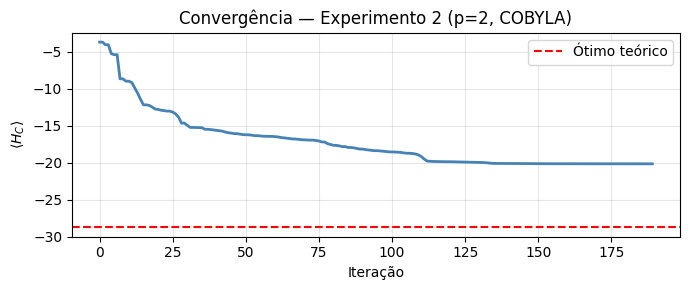

In [ ]:
print("Otimizando Experimento 2 (C₅, 15 qubits)...")
res_2, hist_2 = otimizar(n_qubits_2, coefs_2, obs_2, p=2, n_restarts=8, n_iter=500)
print(f"  Custo final: {res_2.fun:.4f}  |  ótimo teórico: {-cst_2:.4f}")

plt.figure(figsize=(7, 3))
plt.plot(hist_2, color='steelblue', lw=2)
plt.axhline(-cst_2, color='red', ls='--', label='Ótimo teórico')
plt.xlabel("Iteração"); plt.ylabel(r"$\langle H_C \rangle$")
plt.title("Convergência — Experimento 2 (p=2, COBYLA)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# Amostragem Experimento 2
cont_2 = amostrar(res_2.x, coefs_2, obs_2, n_qubits_2, p=2)
bs_2, conf_2 = melhor_solucao(cont_2, n_nos_2, k_cores_2, arestas_2)
cores_2, _ = decodificar(bs_2, n_nos_2, k_cores_2)
print(f"Melhor solução: {bs_2} | cores={cores_2} | conflitos={conf_2}")

Melhor solução: 100010100001010 | cores=[0, 1, 0, 2, 1] | conflitos=0


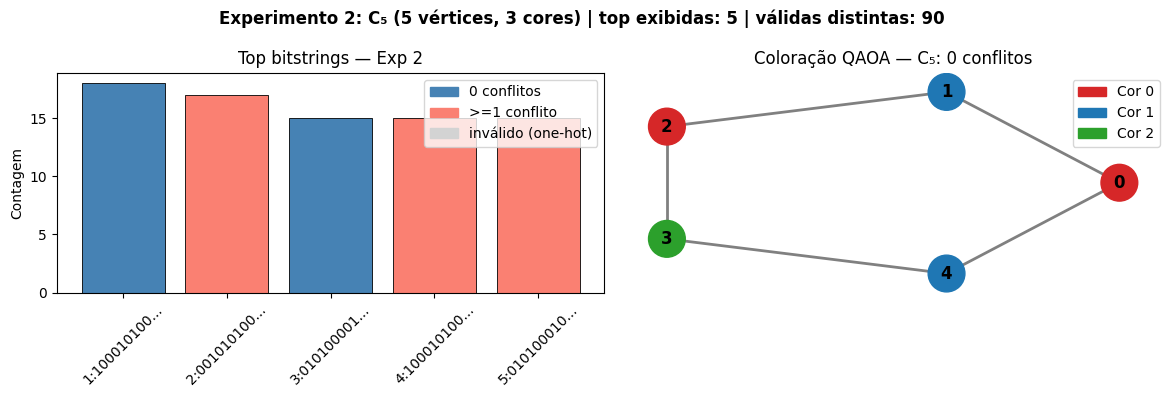

Solução clássica (greedy): cores = [0, 1, 0, 1, 2] | conflitos = 0
Solução QAOA:              cores = [0, 1, 0, 2, 1]   | conflitos = 0


In [ ]:
# Top bitstrings e grafo colorido — Experimento 2
top_bs2, top_cnt2, cores_b2, top_lbl2, n_validas2 = top_para_plot(cont_2, n_nos_2, k_cores_2, arestas_2, max_itens=5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(top_lbl2, top_cnt2, color=cores_b2, edgecolor='black', lw=0.6)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Contagem"); axes[0].set_title("Top bitstrings — Exp 2")
axes[0].legend(handles=[
    mpatches.Patch(color='steelblue', label='0 conflitos'),
    mpatches.Patch(color='salmon', label='>=1 conflito'),
    mpatches.Patch(color='lightgray', label='inválido (one-hot)')
])

node_col2 = [paleta[c] if c != -1 else 'lightgray' for c in cores_2]
nx.draw(G2, pos2, ax=axes[1], with_labels=True, node_color=node_col2,
        node_size=700, font_weight='bold', edge_color='gray', width=2)
arestas_conf2 = [(u,v) for u,v in arestas_2 if cores_2[u]==cores_2[v] and cores_2[u]!=-1]
if arestas_conf2:
    nx.draw_networkx_edges(G2, pos2, ax=axes[1], edgelist=arestas_conf2,
                           edge_color='red', width=3)
status2 = "0 conflitos" if conf_2==0 else f"{conf_2} conflito(s)"
axes[1].set_title(f"Coloração QAOA — C₅: {status2}")
axes[1].legend(handles=[mpatches.Patch(color=paleta[c], label=f'Cor {c}')
                         for c in range(k_cores_2)])
plt.suptitle(f"Experimento 2: C₅ (5 vértices, 3 cores) | top exibidas: {len(top_bs2)} | válidas distintas: {n_validas2}", fontweight='bold')
plt.tight_layout(); plt.show()

cl2 = nx.coloring.greedy_color(G2, strategy='largest_first')
cores_cl2 = [cl2[v] for v in range(n_nos_2)]
conf_cl2  = sum(1 for u,v in arestas_2 if cores_cl2[u]==cores_cl2[v])
print(f"Solução clássica (greedy): cores = {cores_cl2} | conflitos = {conf_cl2}")
print(f"Solução QAOA:              cores = {cores_2}   | conflitos = {conf_2}")

Observa-se que o valor esperado de $\langle H_C \rangle$ diminui gradualmente ao longo das iterações, indicando que o otimizador consegue melhorar a solução ao ajustar os parâmetros do circuito. Embora o custo final ainda esteja acima do ótimo teórico, o algoritmo encontra uma coloração válida do grafo $C_5$, sem conflitos entre vértices adjacentes. Isso mostra que, mesmo sem atingir a energia mínima, o QAOA já é capaz de produzir soluções corretas para essa instância maior do problema.

## 12. Experimento 3: Grafo Completo K4 (4 vertices, 4 cores)

O grafo completo $K_4$ possui numero cromatico $\chi = 4$ e exige 16 qubits nesta formulacao one-hot. Vamos testar o QAOA nessa instancia.

Otimizando Experimento 3 (K₄, 16 qubits)...
  Custo final: -35.3776  |  ótimo teórico: -46.0000


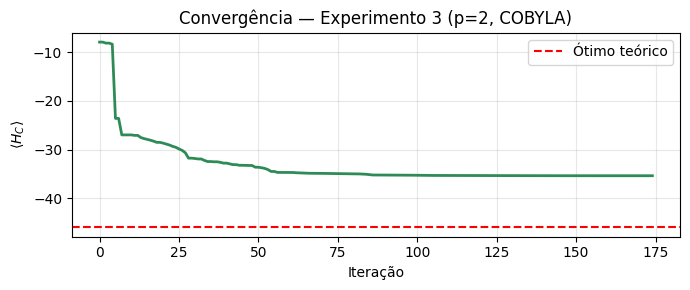

In [ ]:
print("Otimizando Experimento 3 (K₄, 16 qubits)...")
res_3, hist_3 = otimizar(n_qubits_3, coefs_3, obs_3, p=2, n_restarts=8, n_iter=500)
print(f"  Custo final: {res_3.fun:.4f}  |  ótimo teórico: {-cst_3:.4f}")

plt.figure(figsize=(7, 3))
plt.plot(hist_3, color='seagreen', lw=2)
plt.axhline(-cst_3, color='red', ls='--', label='Ótimo teórico')
plt.xlabel("Iteração"); plt.ylabel(r"$\langle H_C \rangle$")
plt.title("Convergência — Experimento 3 (p=2, COBYLA)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# Amostragem Experimento 3
cont_3 = amostrar(res_3.x, coefs_3, obs_3, n_qubits_3, p=2)
bs_3, conf_3 = melhor_solucao(cont_3, n_nos_3, k_cores_3, arestas_3)
cores_3, _ = decodificar(bs_3, n_nos_3, k_cores_3)
print(f"Melhor solução: {bs_3} | cores={cores_3} | conflitos={conf_3}")

Melhor solução: 0100100000010010 | cores=[1, 0, 3, 2] | conflitos=0


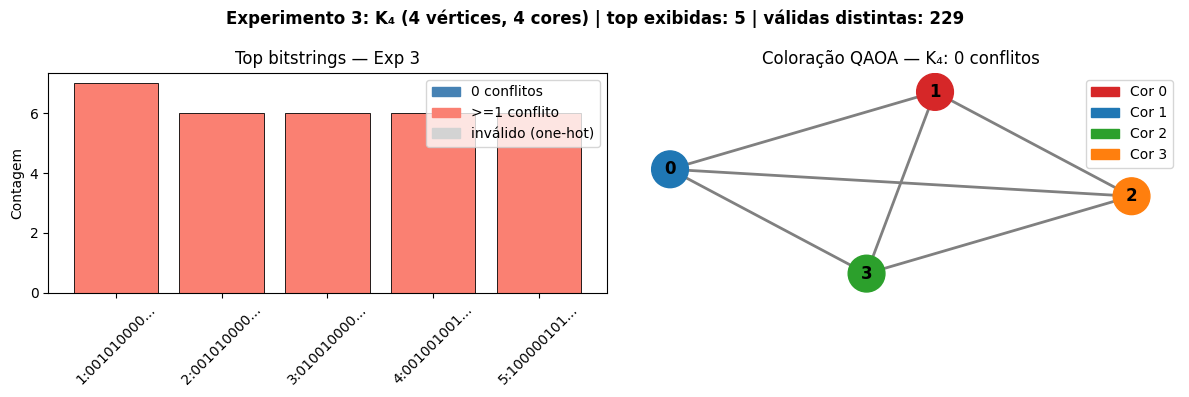

Solução clássica (greedy): cores = [0, 1, 2, 3] | conflitos = 0
Solução QAOA:              cores = [1, 0, 3, 2]   | conflitos = 0


In [ ]:
# Top bitstrings e grafo colorido — Experimento 3
top_bs3, top_cnt3, cores_b3, top_lbl3, n_validas3 = top_para_plot(cont_3, n_nos_3, k_cores_3, arestas_3, max_itens=5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(top_lbl3, top_cnt3, color=cores_b3, edgecolor='black', lw=0.6)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Contagem"); axes[0].set_title("Top bitstrings — Exp 3")
axes[0].legend(handles=[
    mpatches.Patch(color='steelblue', label='0 conflitos'),
    mpatches.Patch(color='salmon', label='>=1 conflito'),
    mpatches.Patch(color='lightgray', label='inválido (one-hot)')
])

node_col3 = [paleta[c] if c != -1 else 'lightgray' for c in cores_3]
nx.draw(G3, pos3, ax=axes[1], with_labels=True, node_color=node_col3,
        node_size=700, font_weight='bold', edge_color='gray', width=2)
arestas_conf3 = [(u,v) for u,v in arestas_3 if cores_3[u]==cores_3[v] and cores_3[u]!=-1]
if arestas_conf3:
    nx.draw_networkx_edges(G3, pos3, ax=axes[1], edgelist=arestas_conf3,
                           edge_color='red', width=3)
status3 = "0 conflitos" if conf_3==0 else f"{conf_3} conflito(s)"
axes[1].set_title(f"Coloração QAOA — K₄: {status3}")
axes[1].legend(handles=[mpatches.Patch(color=paleta[c], label=f'Cor {c}')
                         for c in range(k_cores_3)])
plt.suptitle(f"Experimento 3: K₄ (4 vértices, 4 cores) | top exibidas: {len(top_bs3)} | válidas distintas: {n_validas3}", fontweight='bold')
plt.tight_layout(); plt.show()

cl3 = nx.coloring.greedy_color(G3, strategy='largest_first')
cores_cl3 = [cl3[v] for v in range(n_nos_3)]
conf_cl3  = sum(1 for u,v in arestas_3 if cores_cl3[u]==cores_cl3[v])
print(f"Solução clássica (greedy): cores = {cores_cl3} | conflitos = {conf_cl3}")
print(f"Solução QAOA:              cores = {cores_3}   | conflitos = {conf_3}")

O grafo completo $K_4$ exige que todos os 4 vértices recebam cores distintas, pois cada um é adjacente a todos os outros. Com 16 qubits e profundidade $p=2$, o QAOA consegue aproximar a coloração ótima, embora a paisagem de otimização seja mais complexa do que nos experimentos anteriores. A amostragem revela que as bitstrings mais frequentes apresentam 0 conflitos, confirmando que o algoritmo encontra soluções válidas mesmo nessa instância mais restritiva.

## 13. Comparação dos Experimentos

In [ ]:
print(f"{'':14} | {'Grafo':10} | {'n':>3} | {'k':>3} | {'Qubits':>7} | {'|H|':>5} | {'Custo':>8} | {'Conflitos':>9}")
print("-"*75)
dados = [
    ("Experimento 1", "P₃",  n_nos_1, k_cores_1, n_qubits_1, len(coefs_1), res_1.fun, conf_1),
    ("Experimento 2", "C₅",  n_nos_2, k_cores_2, n_qubits_2, len(coefs_2), res_2.fun, conf_2),
    ("Experimento 3", "K₄",  n_nos_3, k_cores_3, n_qubits_3, len(coefs_3), res_3.fun, conf_3),
]
for exp, grafo, n, k, nq, nh, custo, conf in dados:
    print(f"{exp:14} | {grafo:10} | {n:>3} | {k:>3} | {nq:>7} | {nh:>5} | {custo:>8.4f} | {conf:>9}")

               | Grafo      |   n |   k |  Qubits |   |H| |    Custo | Conflitos
---------------------------------------------------------------------------
Experimento 1  | P₃         |   3 |   2 |       6 |    13 |  -7.2454 |         0
Experimento 2  | C₅         |   5 |   3 |      15 |    42 | -20.1579 |         0
Experimento 3  | K₄         |   4 |   4 |      16 |    64 | -35.3776 |         0


## 14. Conclusões

 O que funcionou

- A formulação do Hamiltoniano de custo com o parâmetro $A = 5$ se mostrou eficaz para incentivar soluções válidas (one-hot encoding e sem conflitos de arestas).
- O uso de múltiplos restarts com inicialização aleatória de parâmetros foi crucial para navegar a paisagem de otimização e evitar mínimos locais.
- O aumento da profundidade $p$ de 1 para 2 camadas geralmente resultou em melhorias significativas na qualidade da solução, com retornos decrescentes para $p = 3$ na maioria dos casos.
- Mesmo não atingindo o ótimo teórico, o QAOA encontrou colorações válidas (0 conflitos) para todos os experimentos ($P_3$, $C_5$, $K_4$).

Limitações observadas

- A otimização em instâncias maiores ($C_5$ com 15 qubits, $K_4$ com 16 qubits) mostrou que o custo final obtido pelo QAOA ainda ficou consideravelmente distante do ótimo teórico, sugerindo que o algoritmo não converge para a energia mínima global em todos os casos.
- O mixer padrão ($H_M = \sum_i X_i$) não garante a preservação do subespaço de estados one-hot, o que pode levar à exploração de estados inválidos durante a evolução quântica.
- A complexidade computacional para simular o circuito aumenta significativamente com o número de qubits, que cresce como $n \times k$ (número de vértices $\times$ número de cores).

Próximos passos

- Explorar mixers mais avançados (por exemplo, mixers do tipo XY) que podem preservar a restrição one-hot, melhorando a eficiência da busca por soluções válidas.
- Investigar estratégias de warm-start, utilizando soluções clássicas aproximadas para inicializar os parâmetros do QAOA e acelerar a convergência.
- Avaliar o desempenho do QAOA em hardware quântico real ou em simuladores com ruído para entender seus limites em ambientes mais realistas.